**Task 1**

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

# генеруємо 26 випадкових чисел від 0 до 26
random_values = [random.randint(0, 26) for _ in range(26)]
print('Random values:', random_values)

Random values: [5, 17, 9, 26, 13, 24, 2, 25, 12, 22, 14, 7, 7, 18, 20, 19, 7, 5, 19, 1, 18, 3, 6, 2, 23, 14]


In [2]:
def deepest_lake(arr):
    """знаходить найглибше озеро в масиві висот"""
    n = len(arr)
    max_depth = 0
    best_i = 0
    best_j = 0

    # перебираємо всі можливі пари стінок
    for i in range(n - 2):
        for j in range(i + 2, n):
            # рівень води = мінімум з двох стінок
            water_level = min(arr[i], arr[j])
            lake = []
            is_lake = True

            # перевіряємо чи всі точки між стінками нижче рівня води
            for k in range(i + 1, j):
                if arr[k] < water_level:
                    lake.append(arr[k])
                else:
                    is_lake = False
                    break

            # якщо це валідне озеро - рахуємо глибину
            if is_lake and lake:
                depth = water_level - min(lake)
                if depth > max_depth:
                    max_depth = depth
                    best_i = i
                    best_j = j

    return {
        'depth': max_depth,
        'left_wall': best_i,
        'right_wall': best_j,
        'subsequence': arr[best_i:best_j + 1]
    }

In [3]:
# тестуємо на прикладі з завдання
sample = [2, 7, 25, 14, 14, 21, 20, 6, 13, 3, 23, 14, 1, 8, 1, 8, 16, 21, 2, 17, 7, 5, 20, 17, 18, 10]
result = deepest_lake(sample)

print(f"Sample: {sample}")
print(f"Deepest lake depth: {result['depth']}")
print(f"Left wall: index {result['left_wall']} (value {sample[result['left_wall']]})")
print(f"Right wall: index {result['right_wall']} (value {sample[result['right_wall']]})")
print(f"Subsequence: {result['subsequence']}")

# тестуємо на випадкових даних
random_result = deepest_lake(random_values)
print(f"\nRandom values: {random_values}")
print(f"Deepest lake depth: {random_result['depth']}")
print(f"Subsequence: {random_result['subsequence']}")

Sample: [2, 7, 25, 14, 14, 21, 20, 6, 13, 3, 23, 14, 1, 8, 1, 8, 16, 21, 2, 17, 7, 5, 20, 17, 18, 10]
Deepest lake depth: 20
Left wall: index 2 (value 25)
Right wall: index 10 (value 23)
Subsequence: [25, 14, 14, 21, 20, 6, 13, 3, 23]

Random values: [5, 17, 9, 26, 13, 24, 2, 25, 12, 22, 14, 7, 7, 18, 20, 19, 7, 5, 19, 1, 18, 3, 6, 2, 23, 14]
Deepest lake depth: 23
Subsequence: [26, 13, 24, 2, 25]


=== Sample Data ===


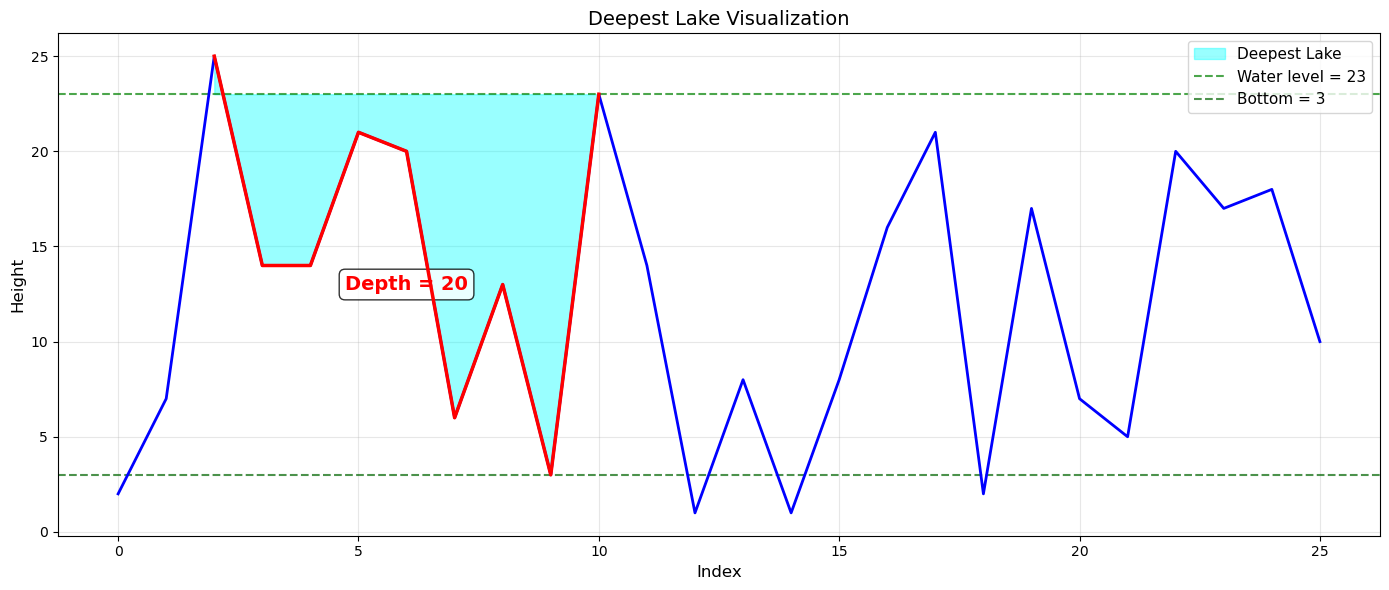


=== Random Data ===


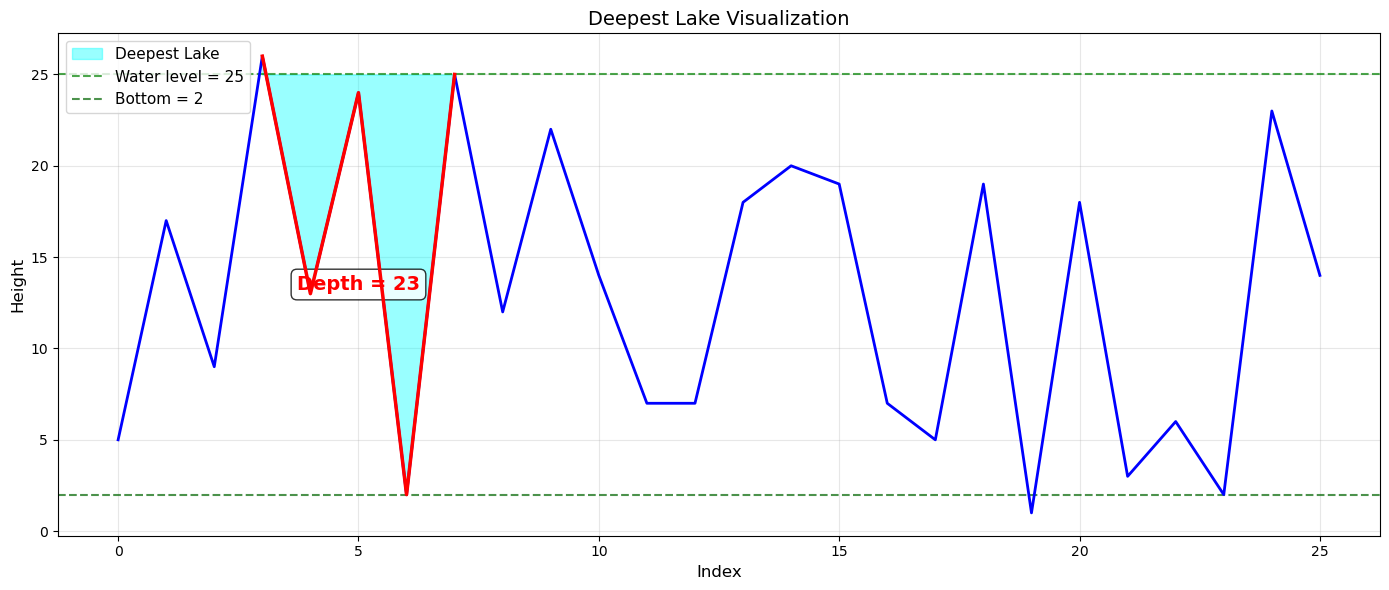

In [4]:
def visualize_lake(arr, result):
    """малює графік з виділеним найглибшим озером"""
    fig, ax = plt.subplots(figsize=(14, 6))
    x = list(range(len(arr)))

    # основна лінія профілю
    ax.plot(x, arr, 'b-', linewidth=2, zorder=3)

    if result['depth'] > 0:
        li = result['left_wall']
        ri = result['right_wall']
        water_level = min(arr[li], arr[ri])

        # заливаємо озеро
        lake_x = list(range(li, ri + 1))
        lake_top = [water_level] * len(lake_x)
        lake_bottom = [arr[idx] for idx in lake_x]

        ax.fill_between(lake_x, lake_bottom, lake_top,
                        alpha=0.4, color='cyan', label='Deepest Lake', zorder=2)

        # лінії рівня води і дна
        ax.axhline(y=water_level, color='green', linestyle='--',
                   alpha=0.7, label=f'Water level = {water_level}')

        sub = arr[li+1:ri]
        min_val = min(sub)
        ax.axhline(y=min_val, color='darkgreen', linestyle='--',
                   alpha=0.7, label=f'Bottom = {min_val}')

        # підпис глибини
        mid_x = (li + ri) / 2
        ax.annotate(f'Depth = {result["depth"]}',
                    xy=(mid_x, (water_level + min_val) / 2),
                    fontsize=14, fontweight='bold', color='red',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

        # виділяємо дно озера червоним
        ax.plot(lake_x, lake_bottom, 'r-', linewidth=2.5, zorder=4)

    ax.set_xlabel('Index', fontsize=12)
    ax.set_ylabel('Height', fontsize=12)
    ax.set_title('Deepest Lake Visualization', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print('=== Sample Data ===')
visualize_lake(sample, result)

print('\n=== Random Data ===')
visualize_lake(random_values, random_result)